In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

**Load mixed data**

In [55]:
stiffness_tag = "3000"
base_dir = "logs"

log_dir = os.path.join(base_dir, stiffness_tag)

ref_data = pd.read_csv('cartesian_ref_xyz1.csv')
ref_data_x = ref_data["x"]
ref_data_y = ref_data["y"]
ref_data_z = ref_data["z"]

t_common = ref_data['time_s'].to_numpy()

ref_x = ref_data_x.to_numpy()
ref_y = ref_data_y.to_numpy()
ref_z = ref_data_z.to_numpy()

xyz_ref = np.stack([ref_x, ref_y, ref_z], axis=1)
xyz_data = pd.read_csv(os.path.join(log_dir, "cartesian_log_xyz1.csv"))[["x", "y", "z"]].to_numpy()
xyz_kernel = pd.read_csv(os.path.join(log_dir, "cartesian_log_kernel_xyz1.csv"))[["x", "y", "z"]].to_numpy()

N = min(len(t_common), len(xyz_data), len(xyz_kernel), len(ref_x), len(ref_y), len(ref_z))

xyz_ref = xyz_ref[:N]
xyz_data = xyz_data[:N]
xyz_kernel = xyz_kernel[:N]

err_no_comp_xyz = xyz_data - xyz_ref
err_comp_xyz = xyz_kernel - xyz_ref

print(xyz_ref.shape)

(64973, 3)


**Plots**

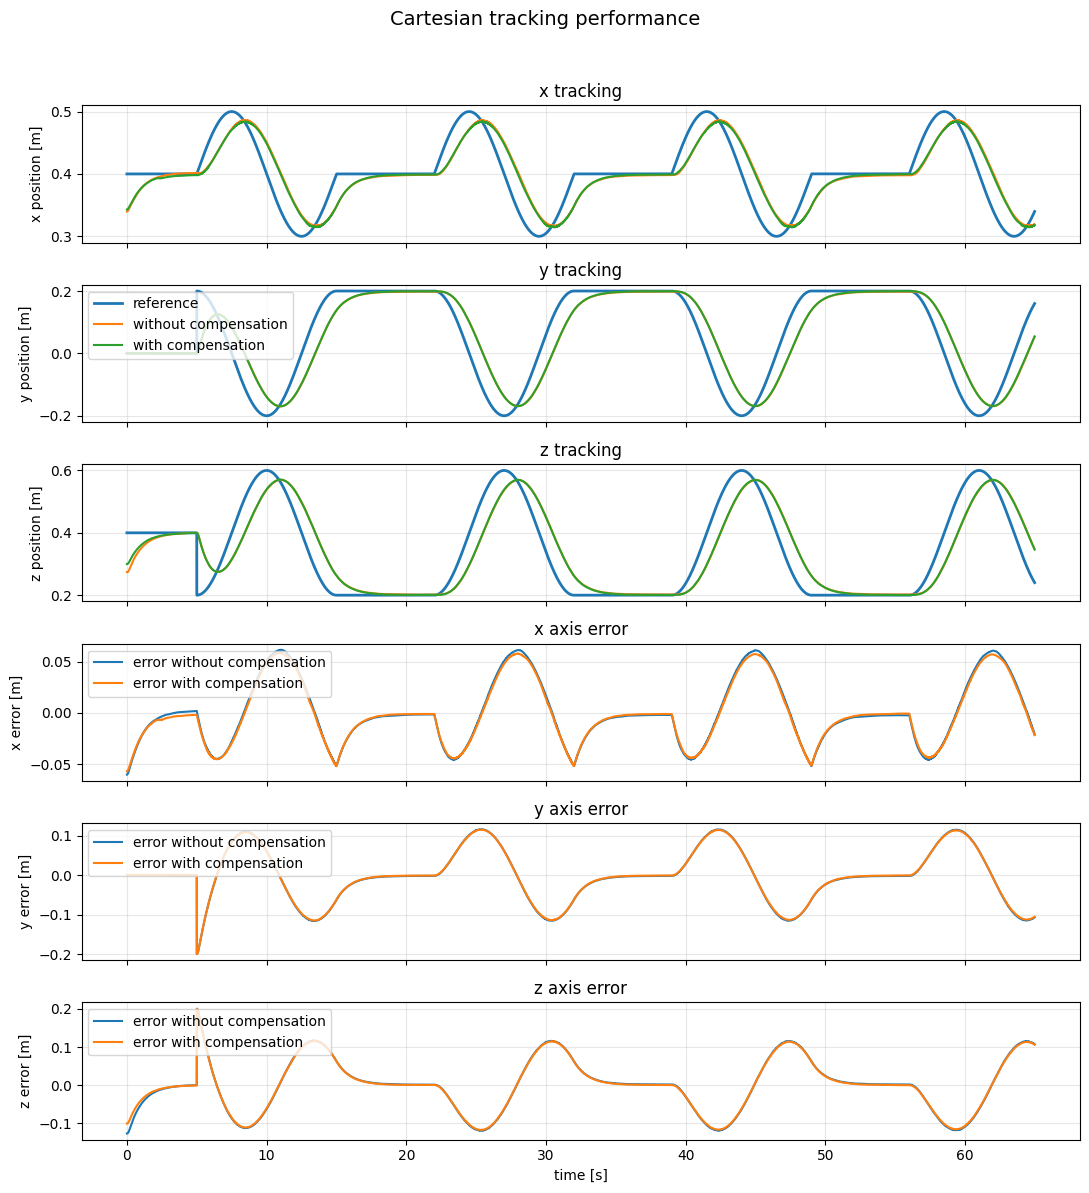

In [56]:
labels = ["x", "y", "z"]
units = "position [m]"

fig, axes = plt.subplots(6, 1, figsize=(11, 12), sharex=True)

# x, y, z tracking (axes 0,1,2)
for i, ax in enumerate(axes[:3]):
    ax.plot(t_common[:N], xyz_ref[:, i], label="reference", linewidth=2)
    ax.plot(t_common[:N], xyz_data[:, i], label="without compensation", linewidth=1.5)
    ax.plot(t_common[:N], xyz_kernel[:, i], label="with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} {units}")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} tracking")

# x, y, z errors (axes 3,4,5)
for i, ax in enumerate(axes[3:6]):
    ax.plot(t_common[:N], err_no_comp_xyz[:, i], label="error without compensation", linewidth=1.5)
    ax.plot(t_common[:N], err_comp_xyz[:, i], label="error with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} error [m]")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} axis error")
    ax.legend(loc="upper left")

axes[1].legend(loc="upper left")
axes[-1].set_xlabel("time [s]")

fig.suptitle("Cartesian tracking performance", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Plot precise error (mixed)**

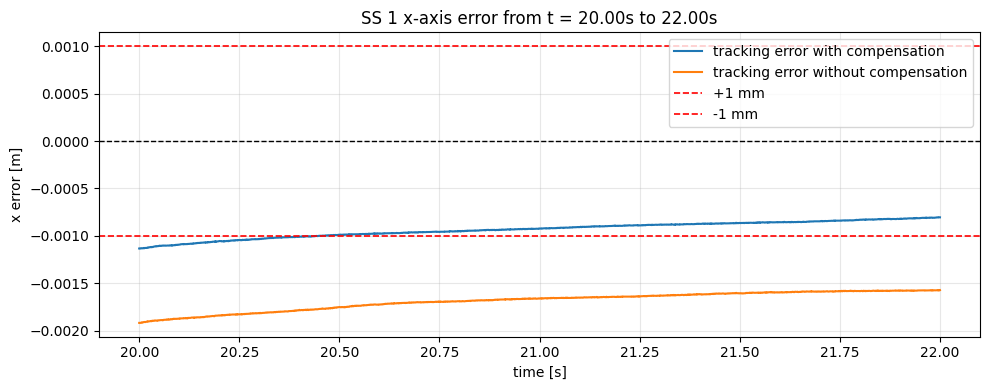

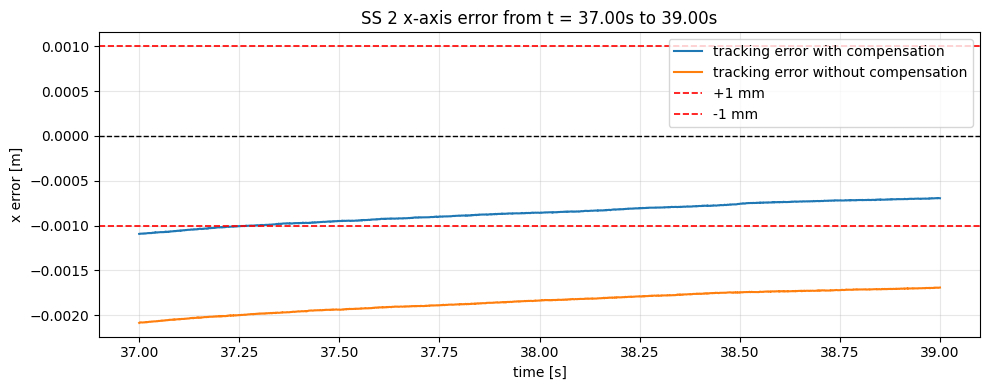

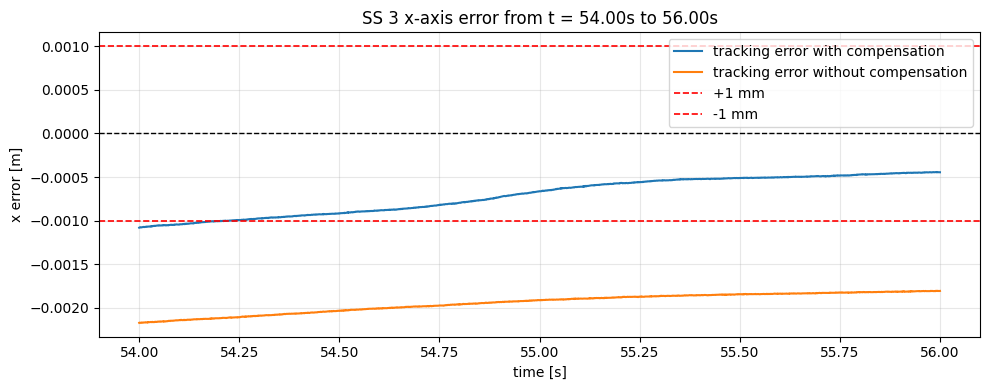

In [58]:

# Steady-state error analysis for x-axis
steady_state_regions = [
    (20000, 22001), # region 1
    (37000, 39001), # region 2
    (54000, 56001), # region 3
]

labels = [f"SS {i+1}" for i in range(len(steady_state_regions))]

for idx, (start, end) in enumerate(steady_state_regions):
    # Safety: clip to valid range
    start = max(0, start)
    end = min(len(t_common), end)

    # Extract window
    t_window = t_common[start:end]
    err_window_comp = err_comp_xyz[start:end, 1] # x-axis error
    err_window = err_no_comp_xyz[start:end, 1] # x-axis error

    # Plot error with compensation

    plt.figure(figsize=(10, 4))
    plt.plot(t_window, err_window_comp, linewidth=1.5, label="tracking error with compensation")
    plt.plot(t_window, err_window, linewidth=1.5, label="tracking error without compensation")

    # Zero line
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    # +- 1 mm thresholds
    plt.axhline(0.001, color='red', linestyle='--', linewidth=1.2, label="+1 mm")
    plt.axhline(-0.001, color='red', linestyle='--', linewidth=1.2, label="-1 mm")

    plt.title(f"{labels[idx]} x-axis error from t = {t_window[0]:.2f}s to {t_window[-1]:.2f}s")
    plt.xlabel("time [s]")
    plt.ylabel("x error [m]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


**Load predictions**

In [32]:
# Load data
data = pd.read_csv(os.path.join(log_dir, "cartesian_log_kernel_xyz.csv"))
tau_ext = data.filter(like="tau_ext_").to_numpy()[1:, :] # shape (T, 7)
predictions = data.filter(like="friction_pred_").to_numpy()[1:, :] # shape (T, 7)

print("tau_ext shape:", tau_ext.shape)
print("predictions shape:", predictions.shape)

tau_ext shape: (64970, 7)
predictions shape: (64970, 7)


**Compare predictions to actual value**

Joint 0: RMSE = 0.1290 Nm
Joint 1: RMSE = 0.4058 Nm
Joint 2: RMSE = 0.1117 Nm
Joint 3: RMSE = 0.2885 Nm
Joint 4: RMSE = 0.0236 Nm
Joint 5: RMSE = 0.1305 Nm
Joint 6: RMSE = 0.0053 Nm


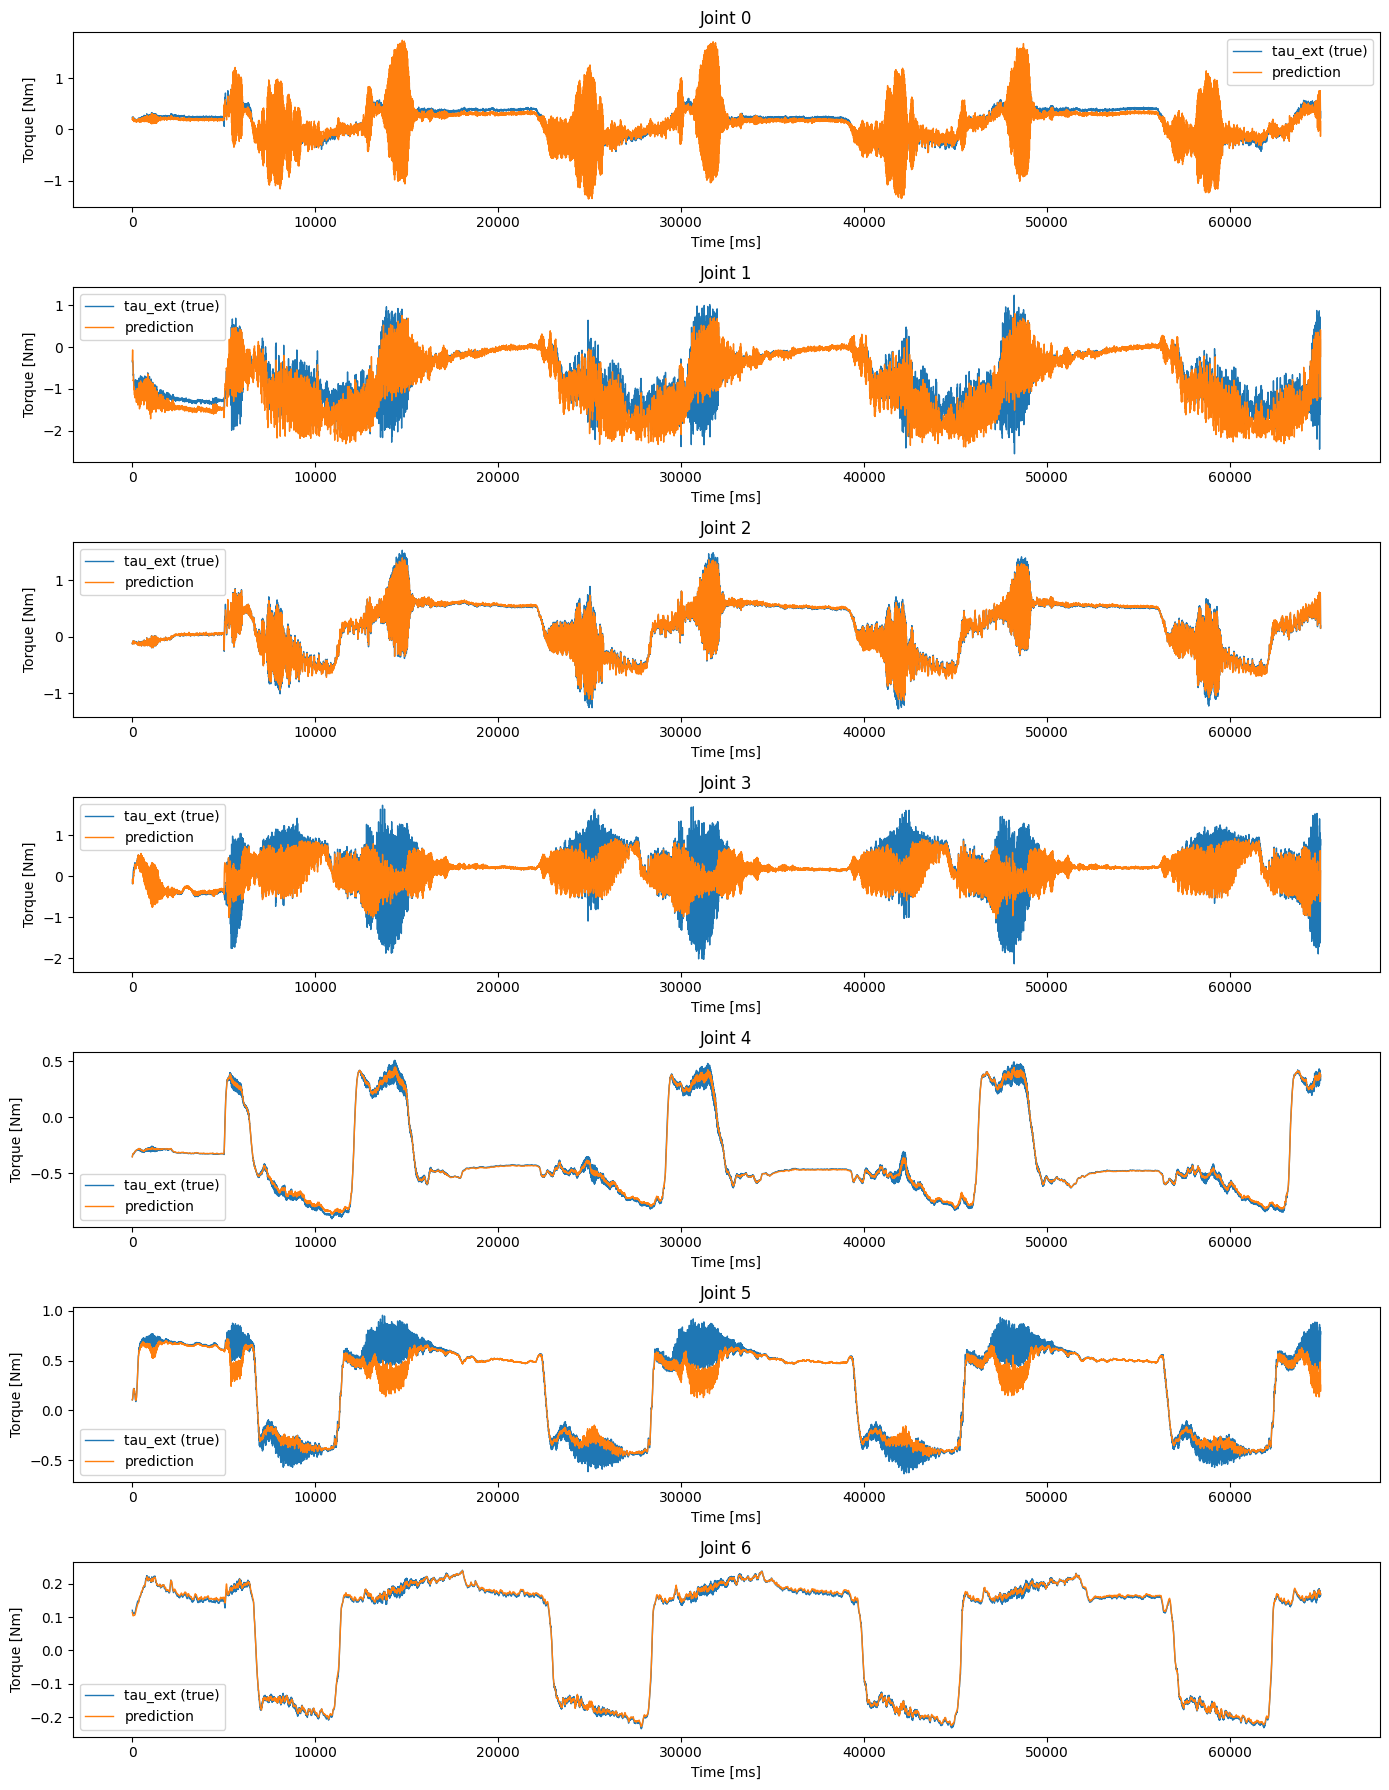

In [33]:
num_joints = tau_ext.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):

    err = tau_ext[:, i] - predictions[:, i]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {i}: RMSE = {rmse:.4f} Nm")
    
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(predictions[:, i], label="prediction", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()

**Compute offline ff_gain**

In [84]:
# LS gain per joint: alpha_j = sum(p*t) / sum(p^2)
num = np.sum(predictions * tau_ext, axis=0)      # shape (7,)
den = np.sum(predictions ** 2, axis=0)           # shape (7,)

# avoid divide-by-zero just in case
eps = 1e-12
ff_gain = num / (den + eps)

print("ff_gain per joint:", ff_gain)

ff_gain per joint: [1.40952237 0.83540393 0.93029335 1.048692   0.99392234 1.00420995
 0.95836993]


**Plots with compensated_tau_ext**

Joint 0: RMSE = 0.0144 Nm
Joint 1: RMSE = 0.0543 Nm
Joint 2: RMSE = 0.0059 Nm
Joint 3: RMSE = 0.0267 Nm
Joint 4: RMSE = 0.0031 Nm
Joint 5: RMSE = 0.0084 Nm
Joint 6: RMSE = 0.0069 Nm


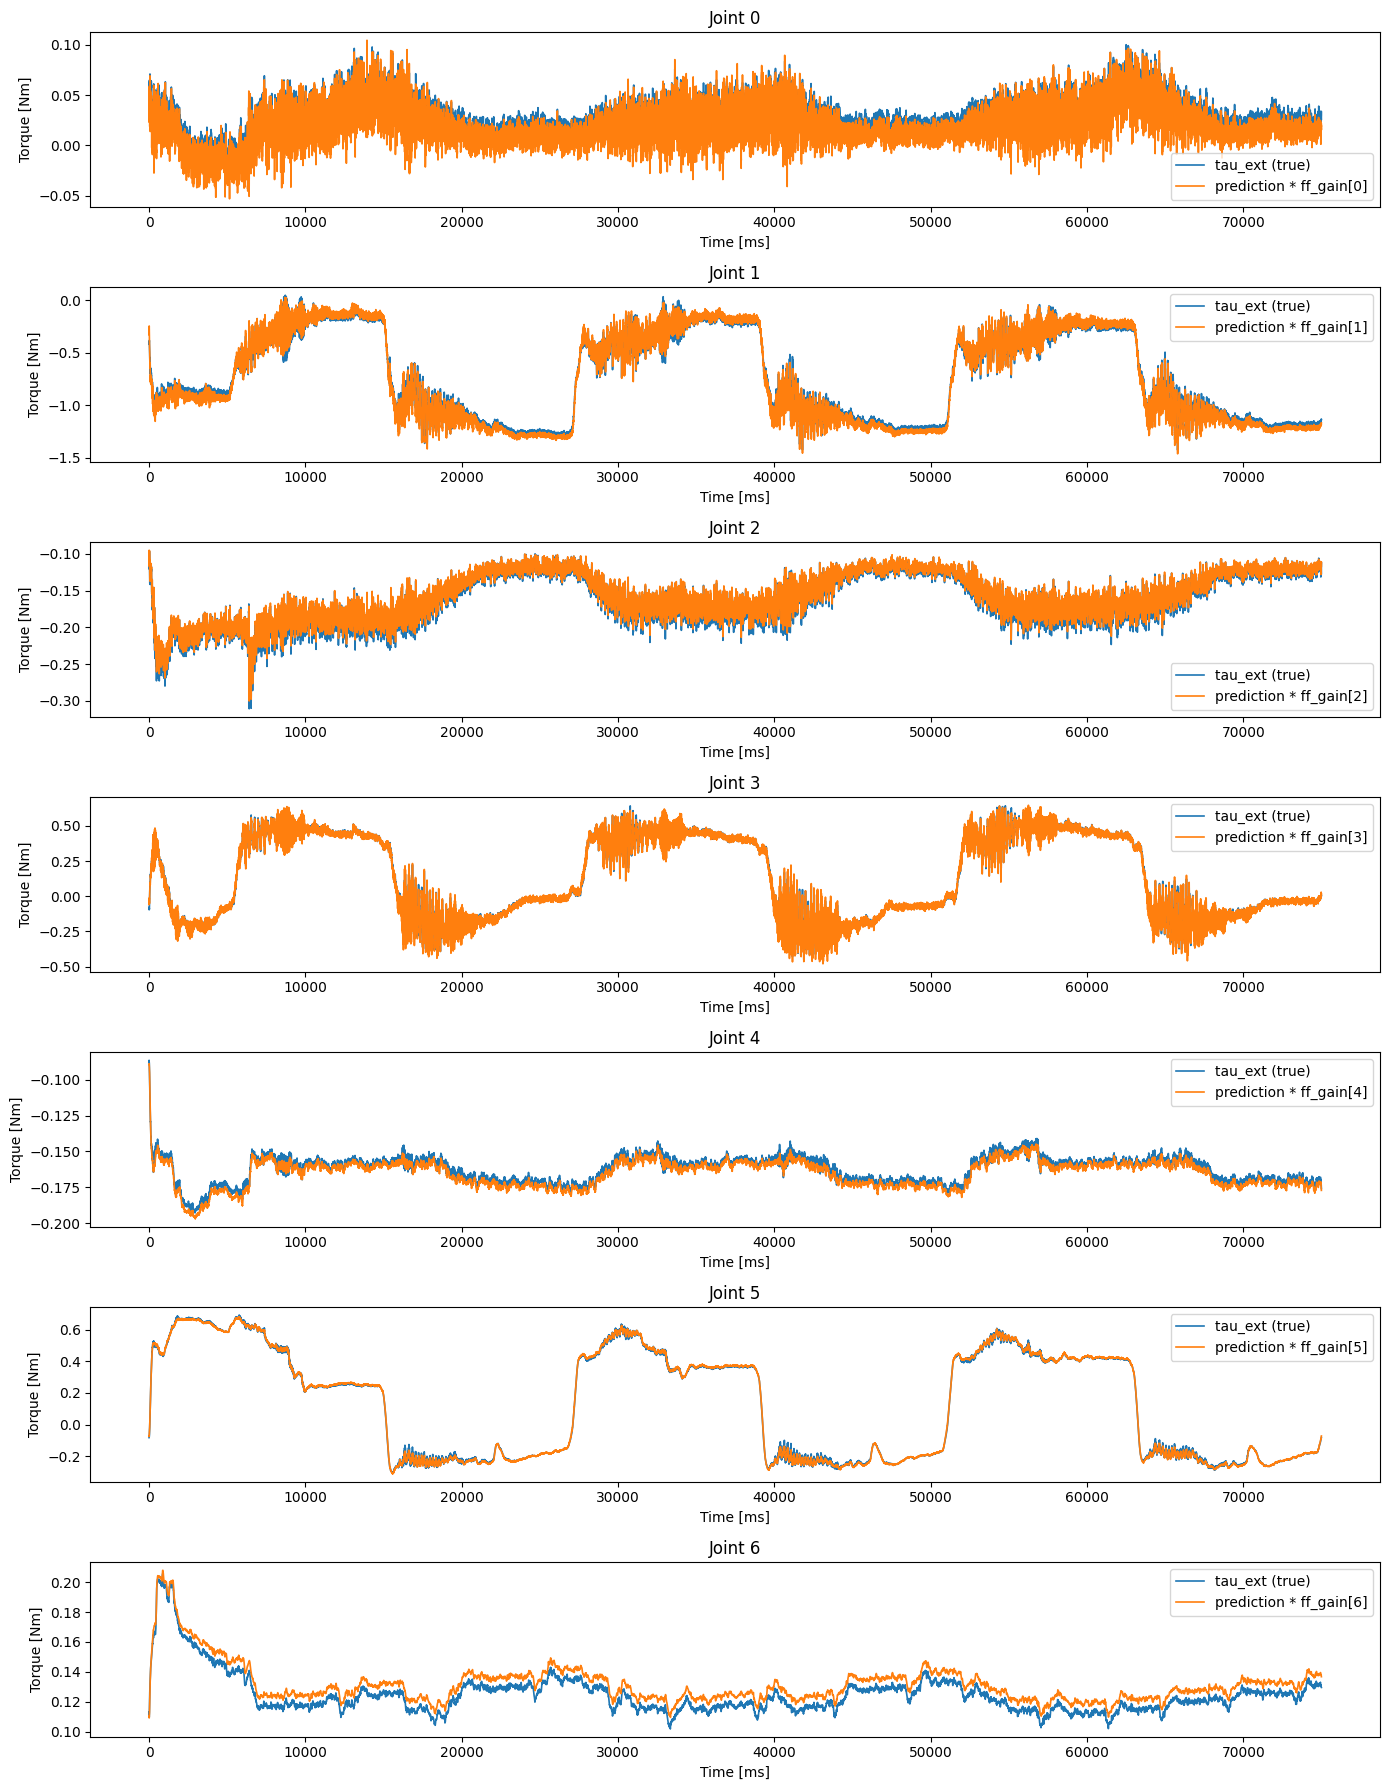

In [ ]:
# Scaled predictions
"""
ff_gain = np.array([1.11,
      0.86,
      0.91,
      1.05,
      1.01,
      1.01,
      1.01])
"""

pred_scaled = predictions * ff_gain  # broadcasting (T,7) * (7,)

# Plotting
plt.figure(figsize=(14, 18))

for j in range(num_joints):

    err = tau_ext[:, j] - pred_scaled[:, j]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {j}: RMSE = {rmse:.4f} Nm")

    plt.subplot(num_joints, 1, j + 1)

    plt.plot(tau_ext[:, j], label="tau_ext (true)", linewidth=1.2)
    plt.plot(pred_scaled[:, j], label=f"prediction * ff_gain[{j}]", linewidth=1.2)

    plt.title(f"Joint {j}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()